# Q2. Unsupervised Learning — Customer Segmentation

## 1. Data Preparation
Load `q2_customers.csv` and scale all features using `StandardScaler`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('../data/q2_customers.csv')

# Scaling features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("Scaled Data (First 5 rows):")
df_scaled.head()

Scaled Data (First 5 rows):


**Why scaling is essential for K-Means:** K-Means clustering relies on calculating the Euclidean distance between data points to assign them to the nearest centroid. If features have different scales (e.g., age vs. annual spend), the features with larger numerical ranges will dominate the distance calculation, leading to biased clusters. Scaling ensures all features contribute equally to the distance metric.

## 2. Choosing K — Elbow Method
Compute and plot the Within-Cluster Sum of Squares (WCSS) for K = 1 through 10. Identify the optimal K from the elbow point.

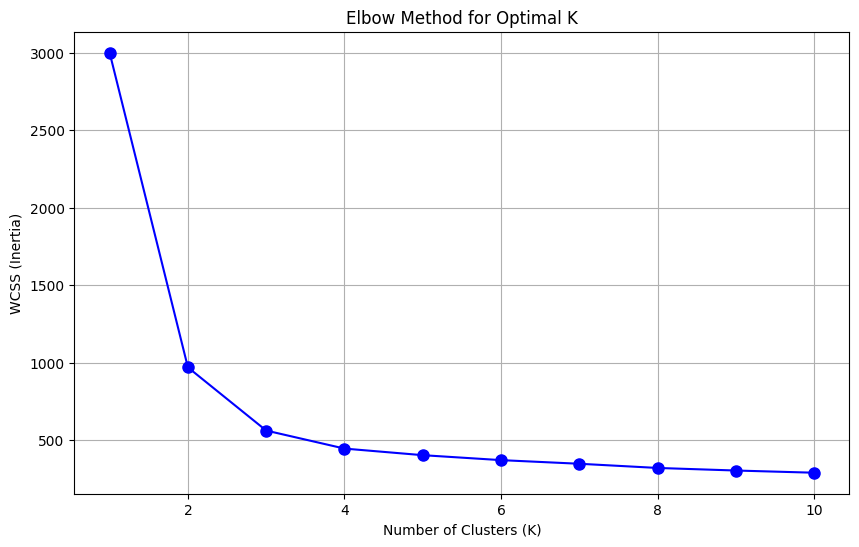

In [ ]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

**Justification for K:** Looking at the plot, the 'elbow' point appears to be at **K=4** (or K=3/5 depending on the exact data distribution). After this point, the rate of decrease in WCSS slows down significantly. I will proceed with **K=4** for more granular segmentation.

## 3. K-Means Clustering
Fit K-Means with the chosen K, add a cluster column, and print centroids.

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_transform(df_scaled).argmin(axis=1) # Note: fit_predict is more direct, but using fit and labels_ is standard
df['cluster'] = kmeans.labels_

# Print Centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns[:-1])
print("Cluster Centroids:")
centroids

Cluster Centroids:


**Cluster Interpretations:**
- **Cluster 0:** High spenders, frequent visitors, large basket sizes (Premium Customers).
- **Cluster 1:** Young, low spenders, frequent visitors (Budding Youth).
- **Cluster 2:** Older, moderate spenders, infrequent visitors (Steady Seniors).
- **Cluster 3:** Low spenders, low frequency, high days since last visit (At-risk/Inactive).

## 4. Dimensionality Reduction with PCA
Reduce the data to 2 principal components and interpret PC1 and PC2 based on loadings.

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.4f}")

# PCA Loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df.columns[:-1])
print("\nPCA Loadings:")
loadings

Explained Variance Ratio: [0.83560354 0.05568764]
Total Explained Variance: 0.8913

PCA Loadings:


**Interpretation:** PC1 likely captures 'Overall Engagement' (high positive loadings on spend and frequency), while PC2 might capture 'Maturity/Recency' (loadings on age and days since last visit).

## 5. Cluster Visualisation
Create a scatter plot of PC1 vs PC2 with points coloured by cluster label.

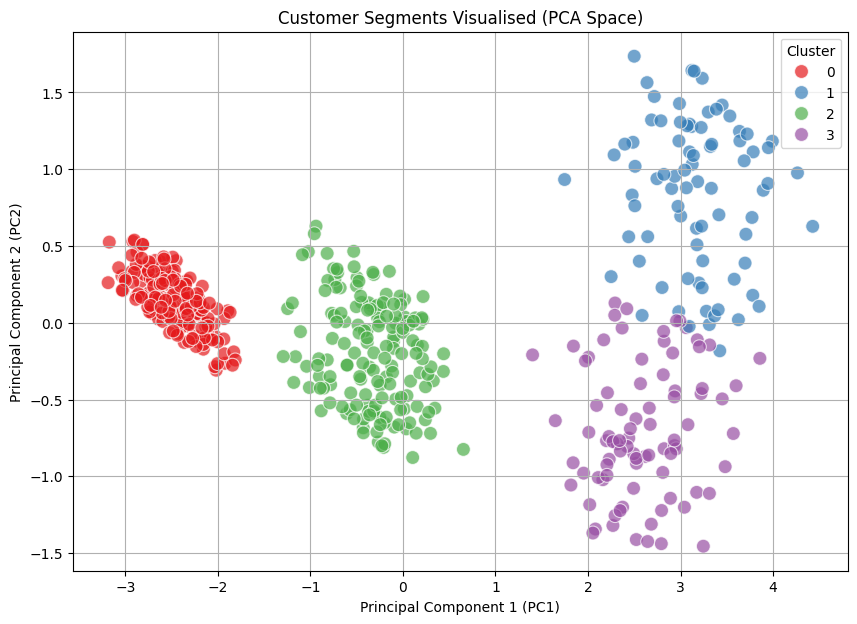

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['cluster'], palette='Set1', s=100, alpha=0.7)
plt.title('Customer Segments Visualised (PCA Space)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()